### First step: Install HOI and dependencies

Please follow the instructions at https://github.com/Mattehub/hoi
(I recommend creating a Conda environment to install everything and work within it.)


In [1]:
%load_ext autoreload
%autoreload 2
from scipy.io import loadmat
import numpy as np
import os
import matplotlib.pyplot as plt
import math
import sys
import zipfile
import urllib
import pandas as pd

In [2]:
import jax
print("JAX Version: ", jax.__version__)
print("Available Devices: ", jax.devices())
# print("Current Backend: ", jax.lib.xla_bridge.get_backend().platform)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX Version:  0.9.2
Available Devices:  [CpuDevice(id=0)]


In [3]:
# --- Detect environment ---
if "google.colab" in sys.modules:
    base_path = "/content/cmha_data"
else:
    base_path = os.path.join(os.getcwd(), "cmha_data")

os.makedirs(base_path, exist_ok=True)

url = "https://zenodo.org/records/10572216/files/cmha-1.0.0.zip?download=1"
zip_path = os.path.join(base_path, "cmha-1.0.0.zip")
expected_folder = os.path.join(base_path, "cmha-1.0.0")

# --- Check if already extracted ---
if os.path.exists(expected_folder):
    print(f"Dataset already extracted at: {expected_folder}")
else:
    # --- Download if missing ---
    if not os.path.exists(zip_path):
        print(f"Downloading dataset from Zenodo to {zip_path}...")
        urllib.request.urlretrieve(url, zip_path)
        print("Download complete.")
    else:
        print("Zip file already exists, skipping download.")

    # --- Extract ---
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(base_path)
    print("\nData extracted at:", base_path)

Dataset already extracted at: /mnt/data_storage/whole_brain_information_theory/cmha_data/cmha-1.0.0


In [4]:
# Load record information
record_metadata = pd.read_csv(f"{base_path}/cmha-1.0.0/data/participants.tsv",delimiter='\t')
# Load fMRI records
data_CoCoMAC = np.load(f"{base_path}/cmha-1.0.0/data/CoCoMac/timeseries.npy")

print("Subjects were recorded under 6 states",record_metadata['cond'].unique())
record_metadata.head(5)
print("\n")
print(f"Data shape {data_CoCoMAC.shape} indicates that there are 156 records from 82 brain regions with 500 samples each")

Subjects were recorded under 6 states <StringArray>
[               'awake',             'ketamine',    'moderate-propofol',
        'deep-propofol', 'moderate-sevoflurane',     'deep-sevoflurane']
Length: 6, dtype: str


Data shape (156, 500, 82) indicates that there are 156 records from 82 brain regions with 500 samples each


In [5]:
all_states = {}

for state_name in record_metadata['cond'].unique():
    all_states[state_name] = {}
    state_df = record_metadata.query("cond==@state_name")
    sub_idx = 1
    for idx, row in state_df.iterrows():
        all_states[row.cond][sub_idx] = data_CoCoMAC[idx]
        sub_idx+=1

### Load the data to compute redundancy and synergy. 
The data should have dimensions (time points, number of regions). If not, you should transpose it when loading (as in this example).

In [6]:
ATOM_INDEX = {
    "rtr": 0,
    "rtu1": 1,
    "rtu2": 2,
    "rts": 3,

    "u1tr": 4,
    "u1tu1": 5,
    "u1tu2": 6,
    "u1ts": 7,

    "u2tr": 8,
    "u2tu1": 9,
    "u2tu2": 10,
    "u2ts": 11,

    "str": 12,
    "stu1": 13,
    "stu2": 14,
    "sts": 15,
}


MEASURES = {

    # already validated ""?""
    "Phi_R": { # Not sure this has an explicit term using atoms
        "add": ["rts", "u1tu2", "u1ts", "u2tu1", "u2ts", "str", "stu1", "stu2", "sts"],  # atoms 3, 6, 7, 9, 11, 12, 13, 14, 15
        "sub": [],
    },

    "Synergy": { # no comment
        "add": ["sts"],  # atom 15
        "sub": [],
    },

    "Redundancy": { # no comment
        "add": ["rtr"],  # atom 0 
        "sub": [],
    },

    "Upward_Causation": { # Good
        "add": ["rts", "u1ts", "u2ts"],   # atoms 3, 7, 11
        "sub": [],
    },

    "Downward_Causation": { # Good
        "add": ["str", "stu1", "stu2"],   # atoms 12, 13, 14
        "sub": [],
    },
 
    "Emergence_Capacity": { # Good
        "add": ["str", "stu1", "stu2", "sts"],   # atoms 12, 13, 14, 15
        "sub": [],
    },

    "Transfer": { # Good
        "add": ["u1tu2", "u2tu1"],        # atoms 6, 9
        "sub": [],
    },

    "Copy": { # Good
        "add": ["u1tr", "u2tr"],          # atoms 4, 8
        "sub": [],
    },

    "Storage": { # Good
        "add": ["rtr","u1tu1", "u2tu2", "sts"],  # 0,5,10,15
        "sub": [],
    },

    "Erasure": { # Good
        "add": ["rtu1", "rtu2"],          # 1,2
        "sub": [],
    },
    
    "Information Storage": { # Good
        "add": ["rtr", "rtu1","u1tr", "u1tu1"],          # 0,1,4,5
        "sub": [],
    },

    "Transfer Entropy": { # Good
        "add": ["u1tr","u1tu2","str","stu2"],          # 4,6,12,14
        "sub": [],
    },

    "Causal Density": { # double synergy to redundance, one for each measure U^i?
        "add": ["u1tr","u1tu2","u2tr","u2tu1","stu1","stu2","str","str"],          # 4,6,8,9,13,14,12,12
        "sub": [],
    },

    "PhiWMS": { # Good. This one doesnt repeat values for each U^i.
        "add": ["rts", "u1tu2", "u1ts", "u2tu1", "u2ts", "str", "stu1", "stu2", "sts"],  # atoms 3, 6, 7, 9, 11, 12, 13, 14, 15 -0
        "sub": ["rtr"],
    },
}


In [ ]:
import numpy as np

def upper_to_sym(vals, N):
    R = np.zeros((N, N))
    iu = np.triu_indices(N, 1)
    R[iu] = vals
    R[(iu[1], iu[0])] = vals
    return R




In [ ]:
from collections import defaultdict
import numpy as np
import os
from alive_progress import alive_bar
from helpers import *

cond_names = np.unique(record_metadata['cond'])

all_results = {cond: defaultdict(list) for cond in cond_names}
phiR_values= {}


for cond in cond_names:
    with alive_bar(total = len(all_states[cond]), title = cond) as bar:
        for subj_idx, subj_ts in enumerate(all_states[cond]):
            print(f"  subject {subj_idx + 1}/{len(all_states[cond])}")   
            res = compute_phiid_measures(all_states[cond][subj_ts], ATOM_INDEX, MEASURES)
            for m, val in res.items():
                all_results[cond][m].append(val)
            bar()

on 0:   subject 1/31
on 1:   subject 2/31
on 1:   subject 3/31
on 1:   subject 4/31
on 1:   subject 5/31
on 1:   subject 6/31
on 1:   subject 7/31
on 1:   subject 8/31
on 1:   subject 9/31
on 1:   subject 10/31
on 1:   subject 11/31
on 1:   subject 12/31
on 1:   subject 13/31
on 1:   subject 14/31
on 1:   subject 15/31
on 1:   subject 16/31
on 1:   subject 17/31
on 1:   subject 18/31
on 1:   subject 19/31
on 1:   subject 20/31
on 1:   subject 21/31
on 1:   subject 22/31
on 1:   subject 23/31
on 1:   subject 24/31
on 1:   subject 25/31
on 1:   subject 26/31
on 1:   subject 27/31
on 1:   subject 28/31
on 1:   subject 29/31
on 1:   subject 30/31
on 1:   subject 31/31
awake |█▎⚠︎                                     | (!) 1/31 [3%] in 13.0s (0.08/s) 
on 0:   subject 1/30
on 1:   subject 2/30
on 1:   subject 3/30
on 1:   subject 4/30
on 1:   subject 5/30
on 1:   subject 6/30
on 1:   subject 7/30
on 1:   subject 8/30
on 1:   subject 9/30
on 1:   subject 10/30
on 1:   subject 11/30
on 1:   sub

In [13]:
np.mean(all_results['awake']['Phi_R'],axis=1)

array([2.15221874])

In [14]:
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."


In [15]:
# Apply global point sizes
plt.rcParams['figure.figsize'] = (15,8)

# 2. Scale up the font sizes dramatically for readability
plt.rc('font', size=18)          # Base font size for general text
plt.rc('axes', titlesize=24)     # Plot title (needs to stand out)
plt.rc('axes', labelsize=20)     # X and Y axis labels (e.g., "Time (ms)")
plt.rc('xtick', labelsize=18)    # X-axis tick numbers
plt.rc('ytick', labelsize=18)    # Y-axis tick numbers
plt.rc('legend', fontsize=18)    # Legend text
plt.rc('figure', titlesize=28)   # Overall figure suptitle (if used)
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['lines.markersize'] = 8


In [ ]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
from statannotations.Annotator import Annotator
import seaborn as sns

def plot_measure(measure_name, all_results, groups):  

    # Overall test
    data = {g:
       np.mean(all_results[g][measure_name], axis=1)
        for g in groups
    }
    
    H, p_kw = kruskal(data['awake'],data['deep-propofol'],data['deep-sevoflurane'], data['ketamine'], data['moderate-propofol'], data['moderate-sevoflurane'])

    # print(f"Kruskal–Wallis H = {H:.3f}, p = {p_kw:.3e}")

    # Pairwise tests
    ps = combinations(data, 2)
    pairs = [(p[0],p[1],data[p[0]],data[p[1]]) for p in ps]


    p_vals = []
    plot_pairs=[]

    for name1, name2, g1, g2 in pairs:
        U, p = mannwhitneyu(g1, g2, alternative="two-sided")
        plot_pairs.append((name1,name2))
        p_vals.append(p)
        #print(f"{name1} vs {name2}: U={U:.1f}, p={p:.3e}")

    # Holm–Bonferroni correction
    p_vals = np.array(p_vals)
    order = np.argsort(p_vals)
    adjusted = np.empty_like(p_vals)

    for i, idx in enumerate(order):
        adjusted[idx] = min(p_vals[idx] * (len(p_vals) - i), 1.0)

    # print("\nHolm-corrected p-values:")
    # for (name1, name2, *_), p_corr in zip(pairs, adjusted):
    #     print(f"{name1} vs {name2}: p_corr = {p_corr:.3e}")

    
    data_groups = [{'Condition': cond, measure_name: v} for cond in data for v in np.asarray(data[cond])[np.isfinite(np.asarray(data[cond]))]]
    data_groups = pd.DataFrame(data_groups)
    fig, ax = plt.subplots(figsize=(14, 8))

    vp = sns.violinplot(data = data_groups, x= 'Condition', y=measure_name, inner=None, hue='Condition', alpha=0.2)

    bp = sns.boxplot(data = data_groups,x= 'Condition', showfliers=False, y=measure_name, hue='Condition', boxprops=dict(alpha=0.5))
    
    sns.stripplot(data = data_groups,x= 'Condition', y=measure_name, hue='Condition', ax=bp, jitter=True)

    annotator = Annotator(bp,plot_pairs, data=data_groups, verbose=False,x= 'Condition', y=measure_name,)
    annotator.configure(
        test=None, 
        hide_non_significant=True, 
        line_height=0.02,    # Optional: Shorten the brackets slightly
        line_offset_to_group=0.05,
        comparisons_correction='Bonferroni'
    ).set_pvalues(pvalues=p_vals).annotate()
    sns.despine()
    plt.xticks(rotation=15)
    plt.ylabel(measure_name.replace("_", " "))
    plt.xlabel('Condición')
    plt.title(measure_name.replace("_", " ") + ' en diferentes estados de consciencia')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


ImportError: The statsmodels package is required to use one of the multiple comparisons correction methods proposed in statannotations. Please install statsmodels or pass `comparisons_correction=None`.

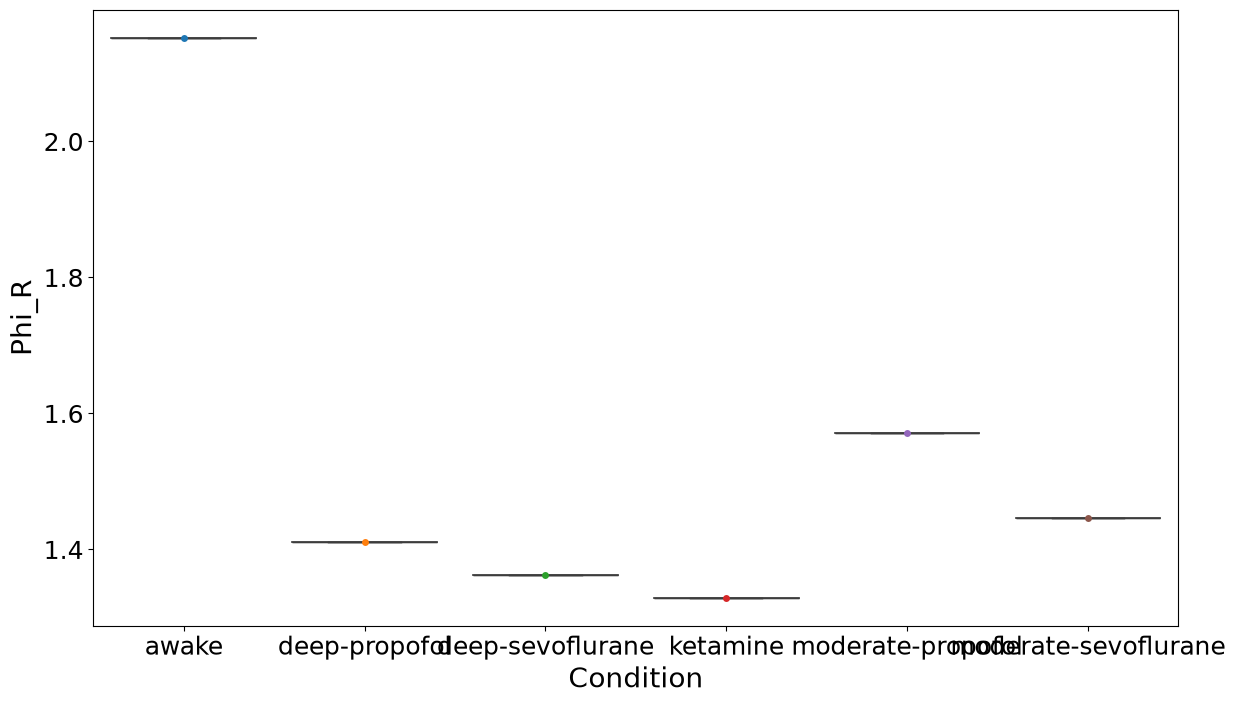

In [18]:
for measure in MEASURES:
    plot_measure(measure, all_results, cond_names)


Here are very basic, minimal Python examples to build intuition about Partial Information Decomposition (PID).
The goal is conceptual clarity, not heavy libraries.

$$X_1,X_2 \rightarrow Y$$
$$
I(X_1, X_2 ; Y)
= \text{Redundant}
+ \text{Unique}_{X_1}
+ \text{Unique}_{X_2}
+ \text{Synergy}
$$

In [ ]:
import numpy as np
from collections import Counter
import math

def entropy(x):
    counts = Counter(x)
    p = np.array(list(counts.values())) / len(x)
    return -np.sum(p * np.log2(p))

def joint_entropy(x, y):
    counts = Counter(zip(x, y))
    p = np.array(list(counts.values())) / len(x)
    return -np.sum(p * np.log2(p))

def mutual_information(x, y):
    return entropy(x) + entropy(y) - joint_entropy(x, y)

def joint_mi(x1, x2, y):
    pairs = list(zip(x1, x2))
    return mutual_information(pairs, y)


def simple_pid(x1, x2, y):
    I1 = mutual_information(x1, y)
    I2 = mutual_information(x2, y)
    I12 = joint_mi(x1, x2, y)

    red = min(I1, I2)
    u1 = I1 - red
    u2 = I2 - red
    syn = I12 - red - u1 - u2

    return {
        "I1": I1,
        "I2": I2,
        "I12": I12,
        "redundancy": red,
        "unique1": u1,
        "unique2": u2,
        "synergy": syn
    }

import numpy as np

def pretty_print_pid(res, decimals=3):
    # Extract components
    components = {
        "Redundancy": res["redundancy"],
        "Unique X1": res["unique1"],
        "Unique X2": res["unique2"],
        "Synergy": res["synergy"],
        "Total I(X1,X2;Y)": res["I12"]
    }
    
    print("\nPID decomposition (bits)")
    print("-" * 35)
    for k, v in components.items():
        print(f"{k:20s}: {v:.{decimals}f}")
    
    # Percentages of total information
    total = res["I12"]
    if total > 0:
        print("\nRelative contribution (%)")
        print("-" * 35)
        for k in ["Redundancy", "Unique X1", "Unique X2", "Synergy"]:
            pct = 100 * components[k] / total
            print(f"{k:20s}: {pct:6.1f}%")

In [ ]:
#Example 1 — Redundancy (copy system)
N = 10000
x1 = np.random.randint(0, 2, N)
x2 = x1.copy()
y = x1.copy()

res = simple_pid(x1, x2, y)
pretty_print_pid(res)



PID decomposition (bits)
-----------------------------------
Redundancy          : 1.000
Unique X1           : 0.000
Unique X2           : 0.000
Synergy             : 0.000
Total I(X1,X2;Y)    : 1.000

Relative contribution (%)
-----------------------------------
Redundancy          :  100.0%
Unique X1           :    0.0%
Unique X2           :    0.0%
Synergy             :    0.0%


In [ ]:
#Example 2 — Unique information
x1 = np.random.randint(0, 2, N)
x2 = np.random.randint(0, 2, N)
y = x1.copy()

res = simple_pid(x1, x2, y)
pretty_print_pid(res)



PID decomposition (bits)
-----------------------------------
Redundancy          : 0.000
Unique X1           : 1.000
Unique X2           : 0.000
Synergy             : 0.000
Total I(X1,X2;Y)    : 1.000

Relative contribution (%)
-----------------------------------
Redundancy          :    0.0%
Unique X1           :  100.0%
Unique X2           :    0.0%
Synergy             :    0.0%


In [ ]:
#Example 3 — Pure synergy (XOR)
x1 = np.random.randint(0, 2, N)
x2 = np.random.randint(0, 2, N)
y = np.logical_xor(x1, x2).astype(int)

res = simple_pid(x1, x2, y)
pretty_print_pid(res)


PID decomposition (bits)
-----------------------------------
Redundancy          : 0.000
Unique X1           : 0.000
Unique X2           : 0.000
Synergy             : 1.000
Total I(X1,X2;Y)    : 1.000

Relative contribution (%)
-----------------------------------
Redundancy          :    0.0%
Unique X1           :    0.0%
Unique X2           :    0.0%
Synergy             :  100.0%


In [ ]:
#Example 4 — Mixed case (partial synergy)
p = 0.5  # probability of XOR vs copy

x1 = np.random.randint(0, 2, N)
x2 = np.random.randint(0, 2, N)

xor = np.logical_xor(x1, x2)
y = np.where(np.random.rand(N) < p, xor, x1).astype(int)

res = simple_pid(x1, x2, y)
pretty_print_pid(res)


PID decomposition (bits)
-----------------------------------
Redundancy          : 0.000
Unique X1           : 0.180
Unique X2           : 0.000
Synergy             : 0.321
Total I(X1,X2;Y)    : 0.502

Relative contribution (%)
-----------------------------------
Redundancy          :    0.1%
Unique X1           :   35.9%
Unique X2           :    0.0%
Synergy             :   64.0%


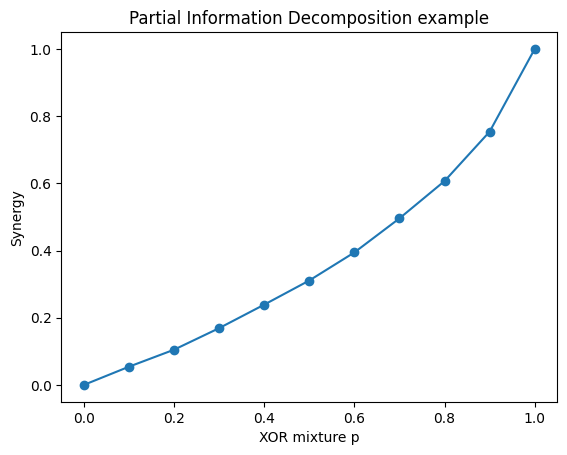

In [ ]:
ps = np.linspace(0,1,11)
syns = []

for p in ps:
    x1 = np.random.randint(0, 2, N)
    x2 = np.random.randint(0, 2, N)
    xor = np.logical_xor(x1, x2)
    y = np.where(np.random.rand(N) < p, xor, x1).astype(int)
    
    syns.append(simple_pid(x1,x2,y)["synergy"])

import matplotlib.pyplot as plt
plt.plot(ps, syns, 'o-')
plt.xlabel("XOR mixture p")
plt.ylabel("Synergy")
plt.title("Partial Information Decomposition example")
plt.show()

/tmp/ipykernel_187609/1603255554.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


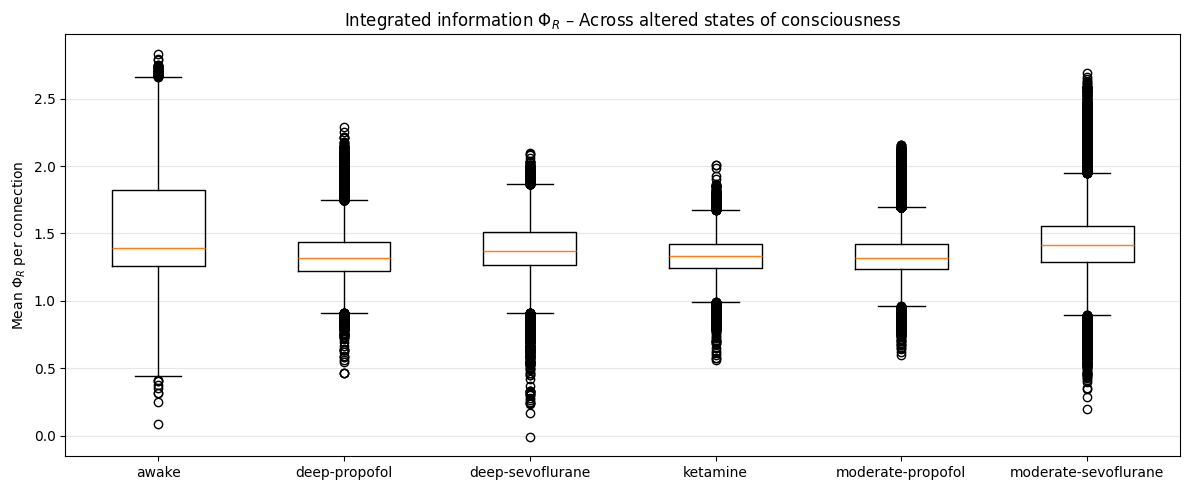

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

phiR_values = {g:
        np.asarray(all_results[g]['Phi_R'])[np.isfinite(all_results[g]['Phi_R'])]
        for g in cond_names
}

data_to_plot = [np.asarray(phiR_values[cond])[~np.isnan(phiR_values[cond])] for cond in phiR_values]

plt.figure(figsize=(12, 5))
plt.boxplot(
    data_to_plot,
    labels=[cond for cond in phiR_values],
    showfliers=True
)

plt.ylabel(r"Mean $\Phi_R$ per connection")
plt.title(r"Integrated information $\Phi_R$ – Across altered states of consciousness")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()




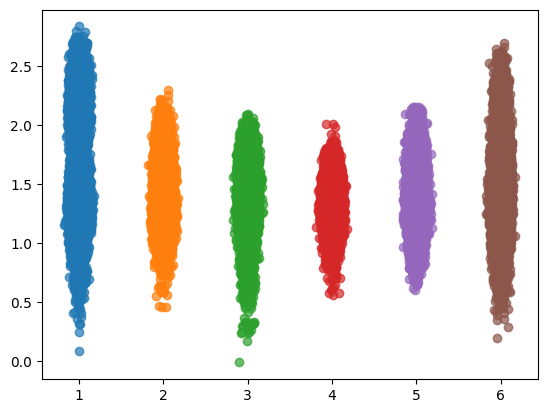

In [ ]:
for i, vals in enumerate(data_to_plot, start=1):
    x = np.random.normal(i, 0.04, size=len(vals))
    plt.scatter(x, vals, alpha=0.7, zorder=3)

plt.show()


In [ ]:
import numpy as np

# groups = ["Controls", "Anoxic", "Traumatic"]

# vals_ctrl = np.asarray(phiR_values["Controls"])
# vals_anox = np.asarray(phiR_values["Anoxic"])
# vals_trau = np.asarray(phiR_values["Traumatic"])

# vals_ctrl = vals_ctrl[np.isfinite(vals_ctrl)]
# vals_anox = vals_anox[np.isfinite(vals_anox)]
# vals_trau = vals_trau[np.isfinite(vals_trau)]

data_groups = [np.asarray(phiR_values[cond])[np.isfinite(np.asarray(phiR_values[cond]))] for cond in phiR_values]



In [ ]:
from itertools import combinations

pairs = list(combinations(phiR_values, 2))
pairs

[('awake', 'deep-propofol'),
 ('awake', 'deep-sevoflurane'),
 ('awake', 'ketamine'),
 ('awake', 'moderate-propofol'),
 ('awake', 'moderate-sevoflurane'),
 ('deep-propofol', 'deep-sevoflurane'),
 ('deep-propofol', 'ketamine'),
 ('deep-propofol', 'moderate-propofol'),
 ('deep-propofol', 'moderate-sevoflurane'),
 ('deep-sevoflurane', 'ketamine'),
 ('deep-sevoflurane', 'moderate-propofol'),
 ('deep-sevoflurane', 'moderate-sevoflurane'),
 ('ketamine', 'moderate-propofol'),
 ('ketamine', 'moderate-sevoflurane'),
 ('moderate-propofol', 'moderate-sevoflurane')]

In [ ]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# Overall test
H, p_kw = kruskal(phiR_values['awake'],phiR_values['deep-propofol'],phiR_values['deep-sevoflurane'], phiR_values['ketamine'], phiR_values['moderate-propofol'], phiR_values['moderate-sevoflurane'])

print(f"Kruskal–Wallis H = {H:.3f}, p = {p_kw:.3e}")

# Pairwise tests
ps = combinations(phiR_values, 2)
pairs = [(p[0],p[1],phiR_values[p[0]],phiR_values[p[1]]) for p in ps]


p_vals = []

for name1, name2, g1, g2 in pairs:
    U, p = mannwhitneyu(g1, g2, alternative="two-sided")
    p_vals.append(p)
    print(f"{name1} vs {name2}: U={U:.1f}, p={p:.3e}")

# Holm–Bonferroni correction
p_vals = np.array(p_vals)
order = np.argsort(p_vals)
adjusted = np.empty_like(p_vals)

for i, idx in enumerate(order):
    adjusted[idx] = min(p_vals[idx] * (len(p_vals) - i), 1.0)

print("\nHolm-corrected p-values:")
for (name1, name2, *_), p_corr in zip(pairs, adjusted):
    print(f"{name1} vs {name2}: p_corr = {p_corr:.3e}")


Kruskal–Wallis H = 24494.357, p = 0.000e+00
awake vs deep-propofol: U=6444393926.5, p=0.000e+00
awake vs deep-sevoflurane: U=3799308537.0, p=0.000e+00
awake vs ketamine: U=5332208113.0, p=0.000e+00
awake vs moderate-propofol: U=5372717772.5, p=0.000e+00
awake vs moderate-sevoflurane: U=4436384994.0, p=2.477e-45
deep-propofol vs deep-sevoflurane: U=2697314086.0, p=0.000e+00
deep-propofol vs ketamine: U=4075069444.0, p=5.948e-08
deep-propofol vs moderate-propofol: U=4129691060.0, p=5.806e-01
deep-propofol vs moderate-sevoflurane: U=3020457688.5, p=0.000e+00
deep-sevoflurane vs ketamine: U=3289727642.0, p=0.000e+00
deep-sevoflurane vs moderate-propofol: U=3273625212.5, p=0.000e+00
deep-sevoflurane vs moderate-sevoflurane: U=2477885711.0, p=3.888e-249
ketamine vs moderate-propofol: U=3518525550.0, p=1.745e-13
ketamine vs moderate-sevoflurane: U=2432015408.0, p=0.000e+00
moderate-propofol vs moderate-sevoflurane: U=2504133610.5, p=0.000e+00

Holm-corrected p-values:
awake vs deep-propofol: 

(-0.4199257171154023, 8.245576314926147)

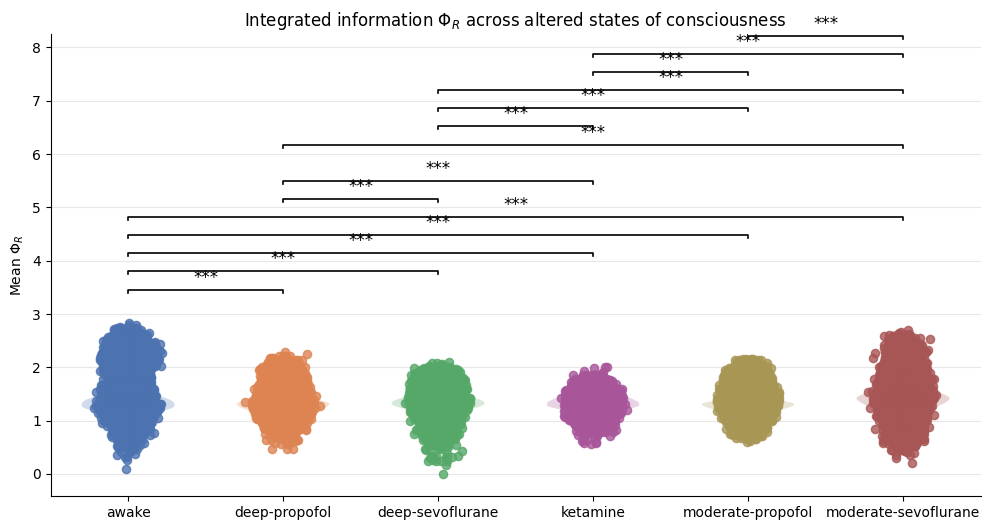

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))

colors = ["#4C72B0", "#DD8452", "#55A868", "#A85599", "#A89655","#A85555"]
positions = range(1, len(cond_names) + 1)

# --- Violin plots ---
vp = ax.violinplot(
    data_groups,
    positions=positions,
    widths=0.6,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("none")

# --- Boxplots ---
bp = ax.boxplot(
    data_groups,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# --- Jittered scatter ---
for i, (vals, color) in enumerate(zip(data_groups, colors), start=1):
    x = np.random.normal(i, 0.05, size=len(vals))
    ax.scatter(x, vals, s=35, color=color, alpha=0.8, zorder=3)

# --- Labels ---
ax.set_xticks(positions)
ax.set_xticklabels(cond_names)
ax.set_ylabel(r"Mean $\Phi_R$")
ax.set_title(r"Integrated information $\Phi_R$ across altered states of consciousness")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

y_max = max(np.max(v) for v in data_groups)

# Push the bars far above the data
y_base = y_max * 1.20        # start 20% above max data
step = y_max * 0.12          # big vertical separation
bar_height = y_max * 0.02    # vertical height of each bracket
text_offset = y_max * 0.02   # space above bar for stars

comparisons = [
    (pa[0], pa[1], adjusted[i] ) for i,pa in enumerate(combinations(positions,2))
]
l = -1
for i, (x1, x2, p_corr) in enumerate(comparisons):
    y = y_base + i * step
    if p_to_star(p_corr)== "n.s.": continue
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bar_height, y + bar_height, y],
        lw=1.2,
        c="black",
        clip_on=False
    ) 

    ax.text(
        (x1 + x2) / 2,
        y + bar_height + text_offset,
        p_to_star(p_corr),
        ha="center",
        va="bottom",
        fontsize=12,
        clip_on=False
    )
    l+=1
# Make sure nothing gets clipped
ax.set_ylim(top=y_base + l * step + y_max * 0.15)

In [ ]:
data_groups

[array([2.36029029, 2.37522721, 2.48474782, ..., 2.27698978, 2.26557585,
        2.11870271], shape=(102951,)),
 array([1.37999615, 1.25498578, 1.32732451, ..., 1.5011065 , 1.29853699,
        1.66011095], shape=(99630,)),
 array([1.36906487, 1.34175614, 1.43868737, ..., 1.39942027, 1.2328748 ,
        1.17528236], shape=(66420,)),
 array([1.23497271, 1.16766393, 1.16994679, ..., 1.39126012, 1.19116025,
        0.94436991], shape=(83025,)),
 array([1.62384772, 1.46861649, 1.37368476, ..., 1.28727215, 1.21589909,
        1.19261968], shape=(83025,)),
 array([1.50391783, 1.16042984, 1.41025767, ..., 1.68483564, 1.4698303 ,
        1.45681   ], shape=(83025,))]

In [ ]:
# base_dir = "/user/rcofreto/home/Documents/CODES/comics_phd-main/Timeseries"

# groups = {
#     "Controls": os.path.join(base_dir, "Controls"),
#     "Anoxic": os.path.join(base_dir, "Anoxic"),
#     "Traumatic": os.path.join(base_dir, "Traumatic"),
# }

n_cols = 4


UC_ATOMS = [
    "rts",     # 3
    "u1ts",    # 7
    "u2ts",    # 11
]

RED_RED_ATOM = "rtr"


import hoi
import numpy as np

def compute_UC_scalar(subject_ts):
    """
    subject_ts : array (T, N_rois)
    returns    : mean Phi_R per connection
    """

    phiid = hoi.metrics.AtomsPhiID(subject_ts)

    atoms = {}

    for atom in UC_ATOMS + [RED_RED_ATOM]:
        atoms[atom] = phiid.fit(
            method="gc",
            minsize=2,
            maxsize=2,
            atoms=[atom]
        )[:, 0]   # upper triangle values

    n_pairs = len(atoms[RED_RED_ATOM])
    N = int((1 + np.sqrt(1 + 8 * n_pairs)) / 2)

    def upper_to_sym(vals):
        R = np.zeros((N, N))
        iu = np.triu_indices(N, 1)
        R[iu] = vals
        R[(iu[1], iu[0])] = vals
        return R

    Phi_R = np.zeros((N, N))

    for atom in UC_ATOMS:
        UC += upper_to_sym(atoms[atom])

    # ⭐ mean per connection
    UC = UC[np.triu_indices(N, 1)].mean()

    return UC

NameError: name 'R_atoms' is not defined

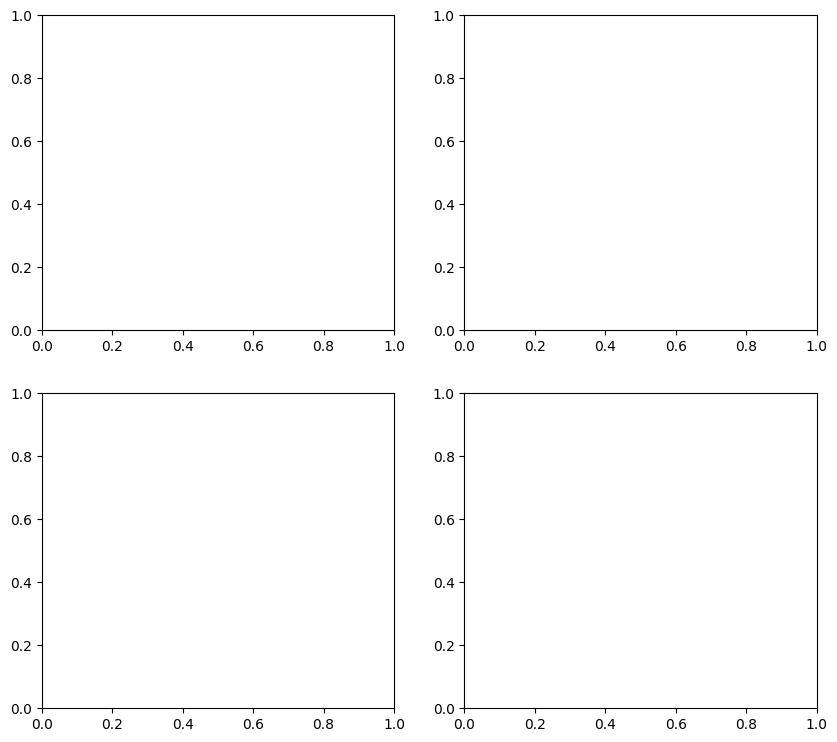

In [ ]:
atoms_to_plot = ["rtr", "rts", "str", "sts"]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, atom in zip(axes.flat, atoms_to_plot):
    im = ax.imshow(R_atoms[atom], cmap="viridis")
    ax.set_title(atom)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
fig.suptitle("φID atom matrices (patient 6)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
vmax = max(np.max(np.abs(R)) for R in R_atoms.values())

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for ax, (atom, R) in zip(axes.flat, R_atoms.items()):
    im = ax.imshow(R, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(atom)
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("All φID atom matrices (patient 6)", fontsize=16)
plt.show()


In [ ]:
R_atoms = {}

for name, vals in atoms_all.items():
    R_atoms[name] = upper_triangular_to_symmetric(vals)


In [ ]:
# atom index → name mapping (explicit)
atom_index_to_name = {
    0: "rtr",
    3: "rts",
    6: "u1tu2",
    7: "u1ts",
    9: "u2tu1",   # or u2ts
    11: "u2ts",  # internal φID atom (exists in out_)
    12: "str",
    13: "stu1",
    14: "stu2",
    15: "sts",
}


In [ ]:
def upper_triangular_to_symmetric(vals):
    vals = np.asarray(vals)
    n_pairs = len(vals)
    N = int((1 + np.sqrt(1 + 8 * n_pairs)) / 2)

    R = np.zeros((N, N))
    iu = np.triu_indices(N, 1)
    R[iu] = vals
    R[(iu[1], iu[0])] = vals
    return R


In [ ]:
# build matrices for required atoms
R_atoms = {
    name: upper_triangular_to_symmetric(atoms_all[name])
    for name in atom_index_to_name.values()
}

# sum selected atoms EXCEPT rtr
Phi_R_matrix = np.zeros_like(next(iter(R_atoms.values())))

for idx, name in atom_index_to_name.items():
    if idx != 0:          # exclude Red→Red for now
        Phi_R_matrix += R_atoms[name]

# subtract persistent redundancy (Red→Red)
Phi_R_matrix -= R_atoms["rtr"]


In [ ]:
Phi_R_value = Phi_R_matrix[np.triu_indices_from(Phi_R_matrix, 1)].sum()


In [ ]:
Phi_R_value 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(Phi_R_matrix, cmap="viridis")
plt.colorbar(label=r"$\Phi_R$")
plt.title(r"$\Phi_R$ (revised) – Patient 6")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()


In [ ]:
data_clean

In [ ]:
n_subj_control = len(data_clean["Control"])
n_subj_mcs     = len(data_clean["MCS"])
n_subj_uws     = len(data_clean["UWS"])

n_subj_control, n_subj_mcs, n_subj_uws

In [ ]:
data_clean["Control"][0].shape
data_clean["MCS"][0].shape
data_clean["UWS"][0].shape


In [ ]:
PHI_R_ATOMS = [
    "rts",      # 3
    "u1tu2",    # 6
    "u1ts",     # 7
    "u2tu1",    # 9
    "u2ts",    # 11
    "str",      # 12
    "stu1",     # 13
    "stu2",     # 14
    "sts",      # 15
]
RED_RED_ATOM = "rtr"


In [ ]:
import numpy as np
import hoi

def compute_phiR_scalar(subject_ts):
    """
    subject_ts : array (time, rois)
    returns    : scalar Phi_R
    """

    phiid = hoi.metrics.AtomsPhiID(subject_ts)

    # compute atoms one by one
    atoms = {}

    for atom in PHI_R_ATOMS + [RED_RED_ATOM]:
        atoms[atom] = phiid.fit(
            method="gc",
            minsize=2,
            maxsize=2,
            atoms=[atom]
        )[:, 0]  # (4005,)

    # infer number of ROIs
    n_pairs = len(atoms[RED_RED_ATOM])
    N = int((1 + np.sqrt(1 + 8 * n_pairs)) / 2)

    # helper
    def upper_to_sym(vals):
        R = np.zeros((N, N))
        iu = np.triu_indices(N, 1)
        R[iu] = vals
        R[(iu[1], iu[0])] = vals
        return R

    # build Phi_R matrix
    Phi_R = np.zeros((N, N))

    for atom in PHI_R_ATOMS:
        Phi_R += upper_to_sym(atoms[atom])

    Phi_R -= upper_to_sym(atoms[RED_RED_ATOM])

    # scalar Phi_R (upper triangle only)
    Phi_R_value = Phi_R[np.triu_indices(N, 1)].mean()

    return Phi_R_value


In [ ]:
cond_names = ["Control", "MCS", "UWS"]

phiR_values = {cond: [] for cond in cond_names}

for cond in cond_names:
    print(f"\nProcessing condition: {cond}")
    for subj_idx in range(len(all_results[cond])):
        print(f"  subject {subj_idx+1}/{len(all_results[cond])}")

        subject_ts = all_results[cond][subj_idx]
        phiR = compute_phiR_scalar(subject_ts)

        phiR_values[cond].append(phiR)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data_to_plot = [
    np.asarray(phiR_values["Control"])[~np.isnan(phiR_values["Control"])],
    np.asarray(phiR_values["MCS"])[~np.isnan(phiR_values["MCS"])],
    np.asarray(phiR_values["UWS"])[~np.isnan(phiR_values["UWS"])],
]
plt.figure(figsize=(6, 5))

plt.boxplot(
    data_to_plot,
    labels=["Control", "MCS", "UWS"],
    showfliers=True
)

plt.ylabel(r"$\Phi_R$")
plt.title(r"Integrated information $\Phi_R$ across conditions")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for i, y in enumerate(data_to_plot, start=1):
    x = np.random.normal(i, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.7, zorder=3)

plt.show()

for cond, vals in zip(["Control", "MCS", "UWS"], data_to_plot):
    n_total = len(phiR_values[cond])
    n_valid = len(vals)
    print(f"{cond}: {n_valid}/{n_total} subjects (NaNs removed)")


In [ ]:
phiR_values["MCS"]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import hoi



In [ ]:
PHI_WMSATOM_INDEX = {
    "rtr": 0,
    "rtu1": 1,
    "rtu2": 2,
    "rts": 3,

    "u1tr": 4,
    "u1tu1": 5,
    "u1tu2": 6,
    "u1ts": 7,

    "u2tr": 8,
    "u2tu1": 9,
    "u2tu2": 10,
    "u2ts": 11,

    "str": 12,
    "stu1": 13,
    "stu2": 14,
    "sts": 15,
}

MEASURES = {

    "Phi_R": {
        "add": ["rts", "u1tu2", "u1ts", "u2tu1", "u2ts",
                "str", "stu1", "stu2", "sts"],
        "sub": [],
    },

    "Integrated Information": {  # Φ_WMS
        "add": ["rts", "u1tu2", "u1ts", "u2tu1", "u2ts",
                "str", "stu1", "stu2", "sts"],
        "sub": ["rtr"],
    },
}


In [ ]:
def simulate_ar(T=200000, c=0.0, burnin=1000, seed=0):
    rng = np.random.default_rng(seed)

    A = np.full((2, 2), 0.4)
    Sigma = np.array([[1.0, c],
                      [c, 1.0]])

    X = np.zeros((T, 2))
    noise = rng.multivariate_normal([0, 0], Sigma, size=T)

    for t in range(T - 1):
        X[t + 1] = A @ X[t] + noise[t]

    return X[burnin:]


In [ ]:
def compute_all_atoms(X):
    """
    Compute all 16 φID atoms separately.
    Returns a dict: atom_name → mean atom value
    """
    phiid = hoi.metrics.AtomsPhiID(X)

    atom_values = {}

    for atom_name in PHI_WMSATOM_INDEX.keys():
        vals = phiid.fit(
            method="gc",
            minsize=2,
            maxsize=2,
            atoms=[atom_name]
        )[:, 0]   # one value per pair

        atom_values[atom_name] = np.mean(vals)

    return atom_values



In [ ]:
def compute_measures_from_atoms(X):
    atom_vals = compute_all_atoms(X)

    results = {}

    for name, spec in MEASURES.items():
        val = 0.0

        for a in spec["add"]:
            val += atom_vals[a]

        for a in spec.get("sub", []):
            val -= atom_vals[a]

        results[name] = val

    return results


In [ ]:
cs = np.linspace(0, 1.0, 15)

phi_r_vals = []
phi_wms_vals = []

for c in cs:
    X = simulate_ar(c=c)
    res = compute_measures_from_atoms(X)

    phi_r_vals.append(res["Phi_R"])
    phi_wms_vals.append(res["Integrated Information"])


In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(cs, phi_wms_vals, 'b-', lw=2, label=r'$\Phi_{\mathrm{WMS}}$')
plt.plot(cs, phi_r_vals, 'r-', lw=2, label=r'$\Phi_R$')

plt.axhline(0, color='k', ls='--', lw=1)

plt.xlabel("Noise correlation")
plt.ylabel("Integrated information")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


In [ ]:
def simulate_synergistic(T=200000, alpha=0.0, sigma=1.0, burnin=1000, seed=0):
    rng = np.random.default_rng(seed)

    X = np.zeros((T, 2))
    noise = rng.normal(scale=sigma, size=(T, 2))

    for t in range(T - 1):
        prod = X[t, 0] * X[t, 1]
        X[t + 1, 0] = np.tanh(alpha * prod) + noise[t, 0]
        X[t + 1, 1] = np.tanh(alpha * prod) + noise[t, 1]

    return X[burnin:]


In [ ]:
alphas = np.linspace(0, 4, 10)

phi_r_vals = []
phi_wms_vals = []

for a in alphas:
    X = simulate_synergistic(alpha=a)
    res = compute_measures_from_atoms(X)

    phi_r_vals.append(res["Phi_R"])
    phi_wms_vals.append(res["Integrated Information"])


In [ ]:
##XOR

In [ ]:
import numpy as np

def simulate_xor(T=200000, p=1.0, burnin=1000, seed=0):
    rng = np.random.default_rng(seed)

    X = np.zeros((T, 2), dtype=int)
    X[0] = rng.integers(0, 2, size=2)

    for t in range(T - 1):

        xor_val = X[t, 0] ^ X[t, 1]

        if rng.random() < p:
            # cross structure (no redundancy)
            X[t + 1, 0] = xor_val
            X[t + 1, 1] = X[t, 0]
        else:
            X[t + 1] = rng.integers(0, 2, size=2)

    return X[burnin:].astype(float)



ps = np.linspace(0, 1, 11)

phi_r_vals = []
phi_wms_vals = []

for p in ps:
    X = simulate_xor(p=p)

    res = compute_measures_from_atoms(X)

    phi_r_vals.append(res["Phi_R"])
    phi_wms_vals.append(res["Integrated Information"])



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(ps, phi_wms_vals, 'b-', lw=2, label=r'$\Phi_{\mathrm{WMS}}$')
plt.plot(ps, phi_r_vals, 'r--', lw=2, label=r'$\Phi_R$')

plt.xlabel("XOR reliability p")
plt.ylabel("Integrated information")
plt.axhline(0, color='k', ls='--')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def simulate_xor(T=200000, p=1.0, burnin=1000, seed=0):
    rng = np.random.default_rng(seed)

    X = np.zeros((T, 2), dtype=int)
    X[0] = rng.integers(0, 2, size=2)

    for t in range(T - 1):

        xor_val = X[t, 0] ^ X[t, 1]

        if rng.random() < p:
            # cross structure (no redundancy)
            X[t + 1, 0] = xor_val
            X[t + 1, 1] = X[t, 0]
        else:
            X[t + 1] = rng.integers(0, 2, size=2)

    return X[burnin:].astype(float)



ps = np.linspace(0, 1, 11)

phi_r_vals = []
phi_wms_vals = []

for p in ps:
    X = simulate_xor(p=p)

    res = compute_measures_from_atoms(X)

    phi_r_vals.append(res["Phi_R"])
    phi_wms_vals.append(res["Integrated Information"])


In [ ]:
import numpy as np

def simulate_gaussian_synergy(T=200000, a=0.0, noise_std=1.0, burnin=1000, seed=0):
    rng = np.random.default_rng(seed)

    X = np.zeros((T, 2))
    noise = rng.normal(scale=noise_std, size=(T, 2))

    for t in range(T - 1):
        z = X[t, 0] + X[t, 1]

        X[t + 1, 0] = a * z + noise[t, 0]
        X[t + 1, 1] = -a * z + noise[t, 1]

    return X[burnin:]


In [ ]:
as_ = np.linspace(0, 2, 15)

phi_r_vals = []
phi_wms_vals = []

for a in as_:
    X = simulate_gaussian_synergy(a=a)
    res = compute_measures_from_atoms(X)

    phi_r_vals.append(res["Phi_R"])
    phi_wms_vals.append(res["Integrated Information"])


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(as_, phi_wms_vals, 'b-', lw=2, label=r'$\Phi_{\mathrm{WMS}}$')
plt.plot(as_, phi_r_vals, 'r--', lw=2, label=r'$\Phi_R$')

plt.xlabel("XOR reliability p")
plt.ylabel("Integrated information")
plt.axhline(0, color='k', ls='--')
plt.legend()
plt.tight_layout()
plt.show()